In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

BASE_DIR = Path("..")
df = pd.read_csv(BASE_DIR / "data/curated/master_panel_geo.csv")
print(df.shape)
df.head(3)

(4283, 35)


,country,country_code,year,reserves_excl_gold_usd,total_reserves_usd,gold_value_usd,gold_share_pct,gold_yoy_change_usd,gold_yoy_change_pct,gold_share_yoy_change,...,gold_share_vs_world,accumulating_during_usd_decline,country_share_of_world_gold_pct,un_alignment_score,un_divergence_score,sanctions_score,sanctions_active,geo_bloc,geo_risk_score,geo_risk_tier
0,Aruba,ABW,2000,2.080100e+08,2.354550e+08,27445000.0,11.66,NaN,NaN,NaN,...,-0.05,0,0.0110,50.0,50.0,0,0,neutral,50.0,medium
1,Aruba,ABW,2001,2.937106e+08,3.213606e+08,27650000.0,8.60,205000.0,0.75,-3.06,...,-2.50,0,0.0112,50.0,50.0,0,0,neutral,50.0,medium
2,Aruba,ABW,2002,3.397279e+08,3.740029e+08,34275000.0,9.16,6625000.0,23.96,0.56,...,-2.39,1,0.0113,50.0,50.0,0,0,neutral,50.0,medium


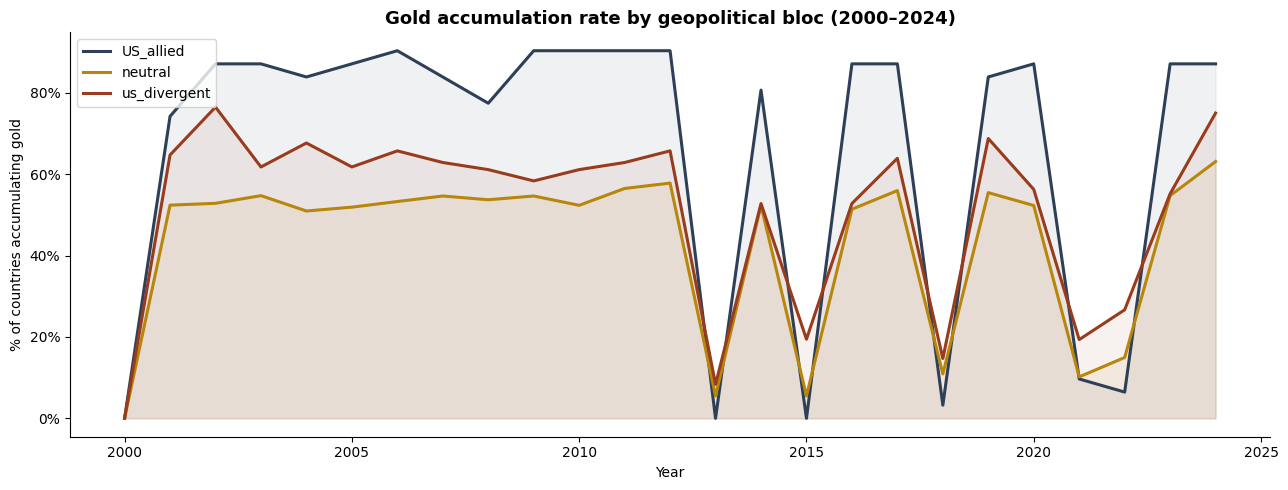

In [2]:
bloc_colors = {
    "US_allied":   "#2E4057",
    "neutral":     "#B8860B",
    "us_divergent":"#993C1D",
}

recent = df[df["year"] >= 2000].copy()
bloc_stats = (
    recent.groupby(["year", "geo_bloc"])["is_accumulating"]
    .mean()
    .reset_index()
    .rename(columns={"is_accumulating": "accumulation_rate"})
)

fig, ax = plt.subplots(figsize=(13, 5))
for bloc, grp in bloc_stats.groupby("geo_bloc"):
    ax.plot(grp["year"], grp["accumulation_rate"],
            label=bloc, color=bloc_colors.get(bloc, "#888"),
            linewidth=2.2)
    ax.fill_between(grp["year"], grp["accumulation_rate"],
                    alpha=0.07, color=bloc_colors.get(bloc, "#888"))

ax.set_title("Gold accumulation rate by geopolitical bloc (2000–2024)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("% of countries accumulating gold")
ax.set_xlabel("Year")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(BASE_DIR / "docs/geo_bloc_accumulation.png", dpi=150)
plt.show()

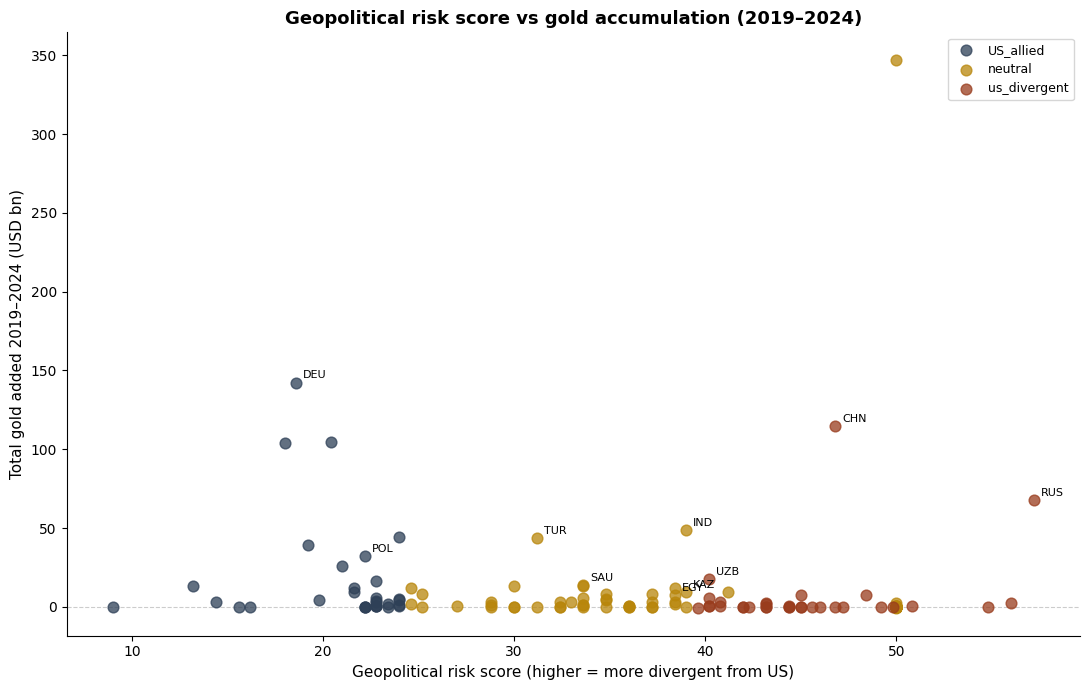

In [3]:
recent5 = df[df["year"] >= 2019].copy()
summary = (
    recent5.groupby(["country", "country_code", "geo_bloc"])
    .agg(
        total_added_bn=("gold_yoy_change_usd", lambda x: x.sum()/1e9),
        geo_risk_score=("geo_risk_score", "mean"),
        avg_gold_share=("gold_share_pct", "mean"),
    )
    .reset_index()
    .dropna()
)
summary = summary[summary["total_added_bn"].abs() < 400]  # remove outliers for scale

fig, ax = plt.subplots(figsize=(11, 7))
for bloc, grp in summary.groupby("geo_bloc"):
    ax.scatter(grp["geo_risk_score"], grp["total_added_bn"],
               color=bloc_colors.get(bloc, "#888"),
               alpha=0.75, s=60, label=bloc, zorder=3)

# label notable countries
label_codes = ["CHN","RUS","IND","TUR","POL","IRN","VEN","UZB","EGY","KAZ","SAU","DEU"]
for _, row in summary[summary["country_code"].isin(label_codes)].iterrows():
    ax.annotate(row["country_code"],
                (row["geo_risk_score"], row["total_added_bn"]),
                textcoords="offset points", xytext=(5, 3), fontsize=8)

ax.axhline(0, color="#ccc", linewidth=0.8, linestyle="--")
ax.set_xlabel("Geopolitical risk score (higher = more divergent from US)", fontsize=11)
ax.set_ylabel("Total gold added 2019–2024 (USD bn)", fontsize=11)
ax.set_title("Geopolitical risk score vs gold accumulation (2019–2024)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(BASE_DIR / "docs/geo_risk_vs_gold.png", dpi=150)
plt.show()

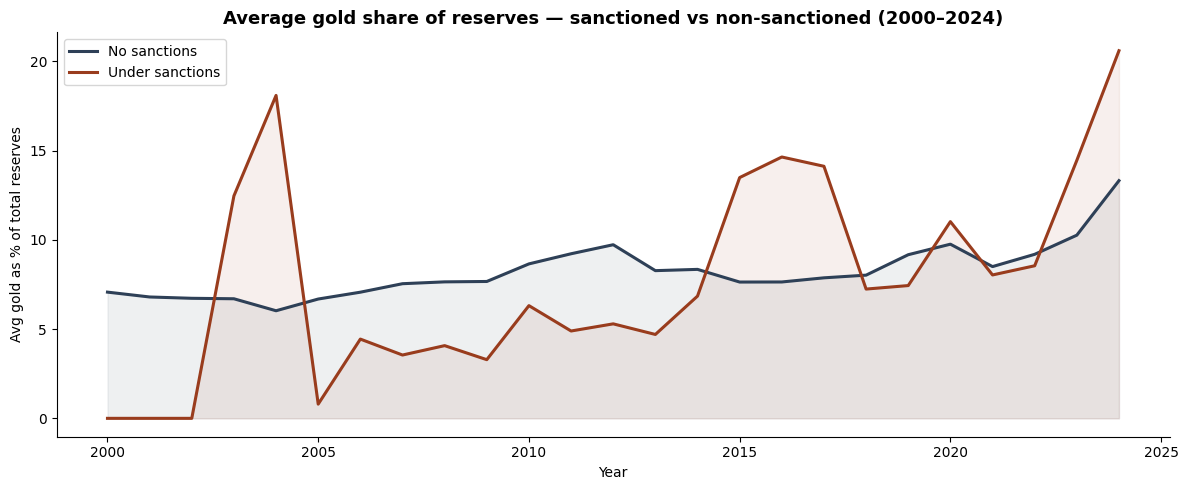

In [4]:
sanc_trend = (
    df.groupby(["year", "sanctions_active"])
    .agg(avg_gold_share=("gold_share_pct", "mean"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for active, grp in sanc_trend.groupby("sanctions_active"):
    label = "Under sanctions" if active == 1 else "No sanctions"
    color = "#993C1D" if active == 1 else "#2E4057"
    ax.plot(grp["year"], grp["avg_gold_share"],
            label=label, color=color, linewidth=2.2)
    ax.fill_between(grp["year"], grp["avg_gold_share"],
                    alpha=0.08, color=color)

ax.set_title("Average gold share of reserves — sanctioned vs non-sanctioned (2000–2024)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Avg gold as % of total reserves")
ax.set_xlabel("Year")
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(BASE_DIR / "docs/sanctions_vs_gold_share.png", dpi=150)
plt.show()

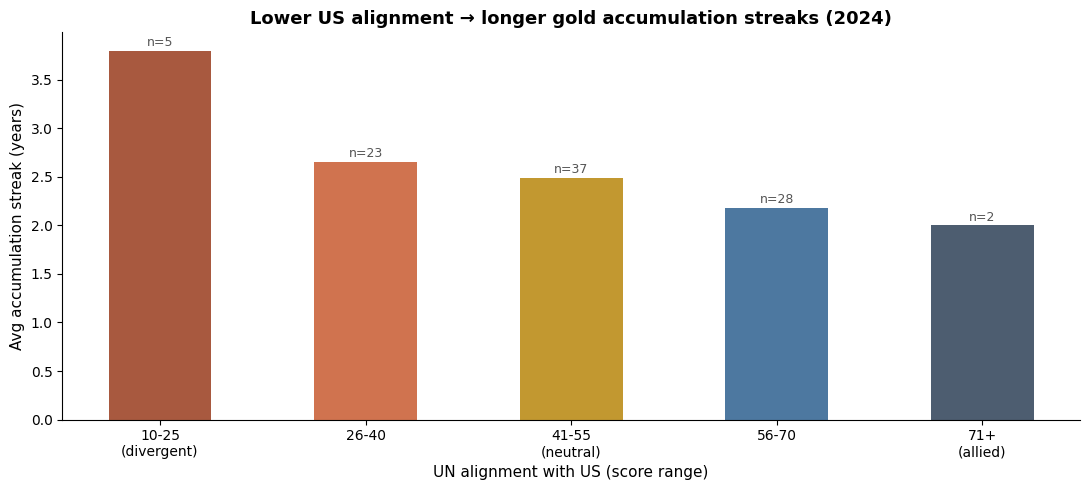

In [5]:
latest = df[df["year"] == 2024].copy()
latest = latest[latest["accumulation_streak"] > 0]
latest["alignment_bin"] = pd.cut(
    latest["un_alignment_score"],
    bins=[0, 25, 40, 55, 70, 100],
    labels=["10-25\n(divergent)", "26-40", "41-55\n(neutral)", "56-70", "71+\n(allied)"]
)

bin_stats = (
    latest.groupby("alignment_bin", observed=True)
    .agg(
        avg_streak=("accumulation_streak", "mean"),
        avg_gold_share=("gold_share_pct", "mean"),
        n_countries=("country_code", "nunique"),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(11, 5))
x = range(len(bin_stats))
bars = ax1.bar(x, bin_stats["avg_streak"],
               color=["#993C1D","#C85A30","#B8860B","#2E6090","#2E4057"],
               alpha=0.85, width=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(bin_stats["alignment_bin"], fontsize=10)
ax1.set_ylabel("Avg accumulation streak (years)", fontsize=11)
ax1.set_xlabel("UN alignment with US (score range)", fontsize=11)
ax1.set_title("Lower US alignment → longer gold accumulation streaks (2024)",
              fontsize=13, fontweight="bold")

for bar, n in zip(bars, bin_stats["n_countries"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"n={n}", ha="center", fontsize=9, color="#555")

sns.despine()
plt.tight_layout()
plt.savefig(BASE_DIR / "docs/un_alignment_vs_streak.png", dpi=150)
plt.show()